# Regularisation

Regularisation is a technique that adds a penalty term to the loss function to discourage overfitting by constraining the magnitude of the learned parameters.

## Ridge Regression

Ridge regression (L2 regularisation) augments the MSE loss with the squared L2 norm of the weight vector:

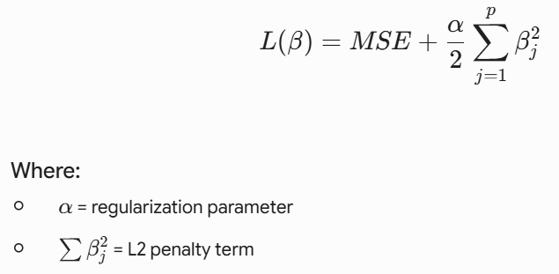

### Ridge Regression — Linear Model

For a linear model with single feature, the loss function is:
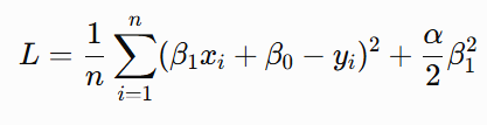
Corresponding partial derivatives are:
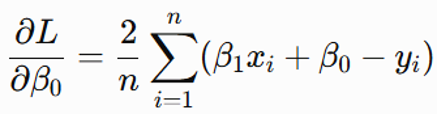
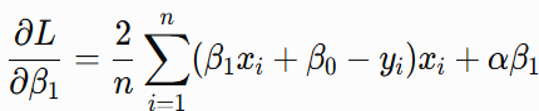

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score

R2 (alpha = 0)  : 0.5863
R2 (alpha = 10) : 0.3540
R2 (alpha = 100): 0.0634


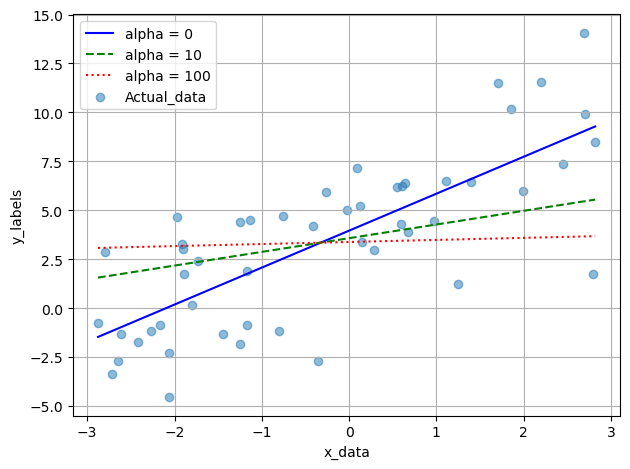

In [5]:
np.random.seed(42)
x = 6*np.random.rand(50) - 3
y = 2* x + 4 + np.random.randn(50) * 3
n = len(x)
def get_constants(x, y, alfa):
    itr_max = 50000
    c, slope = 0.0, 0.0
    eta = 0.0005
    y_pred = c + slope*x
    for itr in range(itr_max):
        y_pred = c + slope*x
        residual = y - y_pred
        d_inter = (-2/n)*np.sum(residual) 
        d_slope = (-2/n)*np.sum(x*residual) + alfa*slope
        c = c - eta*d_inter
        slope = slope - eta*d_slope
    return slope, c
def predict(slope, c, x):
    y_pred = slope*x + c
    return y_pred
slope, c = get_constants(x,y,0)
slope1, c1 = get_constants(x,y,10)
slope2, c2 = get_constants(x,y,100)
y_pred = predict(slope,c,x)
y_pred1 = predict(slope1,c1,x)
y_pred2 = predict(slope2,c2,x)
x_smooth = np.linspace(min(x), max(x), 50)
y_smooth = slope*x_smooth + c
y_smooth1 = slope1*x_smooth + c1
y_smooth2 = slope2*x_smooth + c2

plt.grid()
plt.plot(x_smooth,y_smooth, color = 'blue', label = 'alpha = 0')
plt.plot(x_smooth, y_smooth1, color = 'green', linestyle = '--', label = 'alpha = 10' )
plt.plot(x_smooth,y_smooth2, color = 'red', linestyle = 'dotted', label = 'alpha = 100')
plt.scatter(x,y, label = 'Actual_data', alpha = 0.5)
plt.xlabel('x_data')
plt.ylabel('y_labels')
plt.legend()
plt.tight_layout()
print('R2', '(alpha = 0)  :', f'{r2_score(y,y_pred):.4f}')
print('R2', '(alpha = 10) :', f'{r2_score(y,y_pred1):.4f}')
print('R2', '(alpha = 100):', f'{r2_score(y,y_pred2):.4f}')
plt.show()

R2 (alpha = 0)  : 0.9099
R2 (alpha = 20) : 0.7711
R2 (alpha = 150): 0.6404


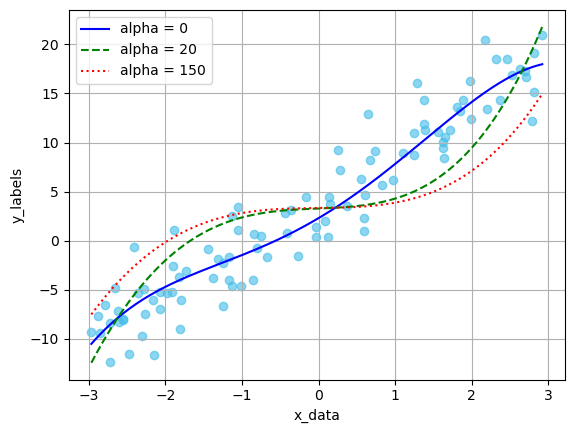

In [6]:
np.random.seed(42)
x = 6 * np.random.rand(100) - 3
y = 5*(x) + 4 + np.random.randn(100) * 3
n = len(x)
def get_constants(x,y,alfa,eta):
    itr_max = 50000
    a,b,c,d,e = 0.0,0.0,0.0,0.0,0.0
    for itr in range(itr_max):
        y_fit = a*(x**4) + b*(x**3) + c*(x**2) + d*x + e 
        residual = y - y_fit
        d_a = (-2/n)*np.sum((x**4)*residual) + alfa*a
        d_b = (-2/n)*np.sum((x**3)*residual) + alfa*b
        d_c = (-2/n)*np.sum((x**2)*(residual)) + alfa*c
        d_d = (-2/n)*np.sum(x*residual) + alfa*d
        d_e =  (-2/n)*np.sum(residual)
        a = a - eta*d_a 
        b = b - eta*d_b
        c = c - eta*d_c
        d = d - eta*d_d
        e = e - eta*d_e
    return a,b,c,d,e
def predict(a,b,c,d,e,x):
    return a*(x**4) + b*(x**3) + c*(x**2) + d*x + e
a,b,c,d,e = get_constants(x,y,0,0.00005)
a1, b1, c1, d1, e1 = get_constants(x,y,20,0.00005)
a2, b2, c2, d2, e2 = get_constants(x,y,150,0.00005)
x_smooth = np.linspace(x.min(), x.max(), 200)
y_smooth = predict(a,b,c,d,e,x_smooth)
y_smooth1 = predict(a1,b1,c1,d1,e1,x_smooth)
y_smooth2 = predict(a2,b2,c2,d2,e2,x_smooth)
y_pred = predict(a,b,c,d,e,x)
y_pred1 = predict(a1,b1,c1,d1,e1,x)
y_pred2 = predict(a2,b2,c2,d2,e2,x)

plt.plot(x_smooth,y_smooth, color = 'blue', label='alpha = 0')
plt.plot(x_smooth, y_smooth1, color = 'green', linestyle = '--', label='alpha = 20' )
plt.plot(x_smooth,y_smooth2, color = 'red', linestyle = 'dotted', label='alpha = 150')
plt.scatter(x,y, color = "#41BCE8", alpha= 0.6)
plt.grid()
plt.xlabel('x_data')
plt.ylabel('y_labels')
plt.legend()

print('R2', '(alpha = 0)  :',f'{r2_score(y,y_pred):.4f}')
print('R2', '(alpha = 20) :',f'{r2_score(y,y_pred1):.4f}')
print('R2', '(alpha = 150):',f'{r2_score(y,y_pred2):.4f}')
plt.show()